# 04 - External Data Collection

## Objective
Collect external data (weather, holidays) that influences pool/spa demand independently of marketing spend.

## Data Sources
- **Weather**: Open-Meteo API (free, no key needed) - Montreal, Quebec
- **Holidays**: Quebec statutory holidays (python-holidays package)

## Input
- `sales_spend_merged.pkl` - Merged sales + media spend (36 months, FY2023-FY2025)

## Output Files
- `external_weather.csv/pkl` - Monthly weather data
- `sales_spend_weather.csv/pkl` - Merged dataset with weather + holidays for modeling

---
## Cell 1: Imports and Setup

In [19]:
import pandas as pd
import numpy as np
import requests
import holidays  # For automatic holiday dates
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Paths
PROJECT_ROOT = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

print("✅ Imports complete")
print(f"📁 Data will be saved to: {DATA_PROCESSED.resolve()}")

✅ Imports complete
📁 Data will be saved to: /Users/raoul/Dev/busa693-clubpiscine/data/processed


---
## Cell 2: Weather Data Configuration

**Location**: Greater Montreal Area (GMA), Quebec  
- Latitude: 45.55  
- Longitude: -73.70  
- This central point represents the broader GMA region

**Coverage**: The Greater Montreal Area includes:
- Montreal Island (downtown, West Island, East End)
- Laval (North Shore)
- Longueuil & South Shore
- Surrounding suburbs

**Rationale**: ~50% of Club Piscine stores are in the GMA. Weather is consistent across the region (all within 50km radius).

**Date Range**:
- Start: 2022-11-01 (FY2023 start)
- End: 2025-10-31 (FY2025 end)

In [20]:
# Greater Montreal Area (GMA) - central coordinates
# This point is more central to the GMA, covering:
# - Montreal Island, Laval, South Shore, West Island, surrounding suburbs
LATITUDE = 45.55
LONGITUDE = -73.70
LOCATION_NAME = "Greater Montreal Area"

# Date range (FY2023 start to FY2025 end or today)
START_DATE = "2022-11-01"
END_DATE = min(datetime.now(), datetime(2025, 10, 31)).strftime("%Y-%m-%d")

print(f"📍 Location: {LOCATION_NAME}")
print(f"   Coordinates: ({LATITUDE}, {LONGITUDE})")
print(f"   Coverage: Montreal Island, Laval, South Shore, West Island")
print(f"📅 Date range: {START_DATE} to {END_DATE}")

📍 Location: Greater Montreal Area
   Coordinates: (45.55, -73.7)
   Coverage: Montreal Island, Laval, South Shore, West Island
📅 Date range: 2022-11-01 to 2025-10-31


---
## Cell 3: Fetch Weather Data from Open-Meteo API

**Open-Meteo API** - Free historical weather data (no API key required)

API Endpoint: `https://archive-api.open-meteo.com/v1/archive`

Variables fetched:
- `temperature_2m_max` - Daily maximum temperature
- `temperature_2m_min` - Daily minimum temperature  
- `temperature_2m_mean` - Daily mean temperature
- `precipitation_sum` - Daily total precipitation (mm)
- `sunshine_duration` - Daily sunshine duration (seconds)

In [21]:
def fetch_openmeteo_weather(latitude, longitude, start_date, end_date):
    """
    Fetch historical weather data from Open-Meteo API.
    
    Open-Meteo is a free weather API that provides historical data
    without requiring an API key.
    
    API Documentation: https://open-meteo.com/en/docs/historical-weather-api
    """
    import requests
    
    # API endpoint for historical data
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    # Parameters
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "temperature_2m_mean",
            "precipitation_sum",
            "sunshine_duration"
        ],
        "timezone": "America/Montreal"
    }
    
    print(f"🌐 Fetching weather data from Open-Meteo API...")
    print(f"   URL: {url}")
    print(f"   Location: ({latitude}, {longitude})")
    print(f"   Period: {start_date} to {end_date}")
    
    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()
        
        # Convert to DataFrame
        daily_data = data['daily']
        df = pd.DataFrame({
            'date': pd.to_datetime(daily_data['time']),
            'temp_max': daily_data['temperature_2m_max'],
            'temp_min': daily_data['temperature_2m_min'],
            'temp_mean': daily_data['temperature_2m_mean'],
            'precipitation': daily_data['precipitation_sum'],
            'sunshine_hours': [s / 3600 if s else 0 for s in daily_data['sunshine_duration']]  # Convert seconds to hours
        })
        
        # Handle any None values
        df = df.fillna(0)
        
        print(f"✅ Successfully fetched {len(df)} days of weather data from Open-Meteo API")
        return df
        
    except requests.exceptions.RequestException as e:
        print(f"❌ API request failed: {e}")
        raise

# Fetch weather data from Open-Meteo API
weather_daily = fetch_openmeteo_weather(LATITUDE, LONGITUDE, START_DATE, END_DATE)

print(f"\n📊 Weather data summary:")
print(weather_daily.describe().round(1))
weather_daily.head(10)

🌐 Fetching weather data from Open-Meteo API...
   URL: https://archive-api.open-meteo.com/v1/archive
   Location: (45.55, -73.7)
   Period: 2022-11-01 to 2025-10-31
✅ Successfully fetched 1096 days of weather data from Open-Meteo API

📊 Weather data summary:
                      date  temp_max  temp_min  temp_mean  precipitation  \
count                 1096    1096.0    1096.0     1096.0         1096.0   
mean   2024-05-01 12:00:00      12.6       3.7        8.2            3.2   
min    2022-11-01 00:00:00     -18.5     -31.0      -26.0            0.0   
25%    2023-08-01 18:00:00       2.6      -4.5       -0.5            0.0   
50%    2024-05-01 12:00:00      13.6       4.6        8.8            0.3   
75%    2025-01-30 06:00:00      23.0      13.6       18.2            3.2   
max    2025-10-31 00:00:00      34.0      25.1       28.8          129.0   
std                    NaN      11.8      11.3       11.3            7.2   

       sunshine_hours  
count          1096.0  
mean    

,date,temp_max,temp_min,temp_mean,precipitation,sunshine_hours
0,2022-11-01,15.6,8.9,11.1,2.2,4.045897
1,2022-11-02,12.6,4.3,8.3,0.0,8.937753
2,2022-11-03,15.4,2.5,9.2,0.0,8.879981
3,2022-11-04,18.3,8.1,12.7,0.0,8.830111
4,2022-11-05,22.5,12.2,17.1,0.0,7.453317
5,2022-11-06,19.9,15.1,17.5,6.0,3.222811
6,2022-11-07,14.9,7.1,12.0,0.0,8.751800
7,2022-11-08,6.9,-1.1,3.8,0.0,8.726119
8,2022-11-09,7.8,-2.7,2.5,0.0,8.685656
9,2022-11-10,16.1,5.3,12.3,1.2,8.273208


---
## Cell 4: Process Weather Data - Create Derived Features

In [22]:
def add_derived_features(df):
    """
    Add derived weather features relevant to pool/spa demand.
    
    Features:
    - temp_above_20: Flag for pool weather (mean temp > 20°C)
    - temp_above_25: Flag for hot days (mean temp > 25°C)
    - heating_degree_days: Measure of cold (base 18°C)
    - cooling_degree_days: Measure of heat (base 18°C)
    - rolling_temp_7d: 7-day rolling average temperature
    """
    df = df.copy()
    
    # Pool weather indicators
    df['temp_above_20'] = (df['temp_mean'] > 20).astype(int)
    df['temp_above_25'] = (df['temp_mean'] > 25).astype(int)
    df['temp_above_15'] = (df['temp_mean'] > 15).astype(int)  # Mild days
    
    # Degree days (base 18°C - standard for HVAC)
    df['heating_degree_days'] = np.maximum(18 - df['temp_mean'], 0)
    df['cooling_degree_days'] = np.maximum(df['temp_mean'] - 18, 0)
    
    # Rolling averages
    df['rolling_temp_7d'] = df['temp_mean'].rolling(window=7, min_periods=1).mean()
    df['rolling_temp_14d'] = df['temp_mean'].rolling(window=14, min_periods=1).mean()
    
    # Rain day flag
    df['rain_day'] = (df['precipitation'] > 1).astype(int)  # More than 1mm
    
    # Extract year and month for aggregation
    df['year'] = df['date'].dt.year
    df['month_num'] = df['date'].dt.month
    
    print(f"✅ Added {len(df.columns) - 6} derived features")
    return df

weather_daily = add_derived_features(weather_daily)
print(f"\nColumns: {weather_daily.columns.tolist()}")
weather_daily.head()

✅ Added 10 derived features

Columns: ['date', 'temp_max', 'temp_min', 'temp_mean', 'precipitation', 'sunshine_hours', 'temp_above_20', 'temp_above_25', 'temp_above_15', 'heating_degree_days', 'cooling_degree_days', 'rolling_temp_7d', 'rolling_temp_14d', 'rain_day', 'year', 'month_num']


,date,temp_max,temp_min,temp_mean,precipitation,sunshine_hours,temp_above_20,temp_above_25,temp_above_15,heating_degree_days,cooling_degree_days,rolling_temp_7d,rolling_temp_14d,rain_day,year,month_num
0,2022-11-01,15.6,8.9,11.1,2.2,4.045897,0,0,0,6.9,0.0,11.100000,11.100000,1,2022,11
1,2022-11-02,12.6,4.3,8.3,0.0,8.937753,0,0,0,9.7,0.0,9.700000,9.700000,0,2022,11
2,2022-11-03,15.4,2.5,9.2,0.0,8.879981,0,0,0,8.8,0.0,9.533333,9.533333,0,2022,11
3,2022-11-04,18.3,8.1,12.7,0.0,8.830111,0,0,0,5.3,0.0,10.325000,10.325000,0,2022,11
4,2022-11-05,22.5,12.2,17.1,0.0,7.453317,0,0,1,0.9,0.0,11.680000,11.680000,0,2022,11


---
## Cell 5: Aggregate Weather Data to Monthly

Match granularity of existing quote/spend data (monthly).

In [23]:
def aggregate_to_monthly(df):
    """
    Aggregate daily weather data to monthly level.
    
    Aggregations:
    - Temperature: mean of daily values
    - Precipitation: sum
    - Sunshine: sum
    - Indicator days: count/sum
    """
    monthly = df.groupby(['year', 'month_num']).agg({
        # Temperature averages
        'temp_max': 'mean',
        'temp_min': 'mean',
        'temp_mean': 'mean',
        
        # Totals
        'precipitation': 'sum',
        'sunshine_hours': 'sum',
        
        # Count of indicator days
        'temp_above_15': 'sum',
        'temp_above_20': 'sum',
        'temp_above_25': 'sum',
        'rain_day': 'sum',
        
        # Degree days (sum)
        'heating_degree_days': 'sum',
        'cooling_degree_days': 'sum',
        
        # Last day of month's rolling average
        'rolling_temp_7d': 'last'
    }).reset_index()
    
    # Rename columns for clarity
    monthly.columns = [
        'year', 'month_num',
        'avg_temp_max', 'avg_temp_min', 'avg_temp_mean',
        'total_precipitation', 'total_sunshine_hours',
        'days_above_15', 'days_above_20', 'days_above_25',
        'rain_days',
        'heating_degree_days', 'cooling_degree_days',
        'rolling_temp_7d_eom'
    ]
    
    # Add French month names to match existing data
    month_names_fr = {
        1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril',
        5: 'Mai', 6: 'Juin', 7: 'Juillet', 8: 'Août',
        9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
    }
    monthly['month'] = monthly['month_num'].map(month_names_fr)
    
    # Round numeric columns
    numeric_cols = monthly.select_dtypes(include=[np.number]).columns
    monthly[numeric_cols] = monthly[numeric_cols].round(2)
    
    print(f"✅ Aggregated to {len(monthly)} months of data")
    return monthly

weather_monthly = aggregate_to_monthly(weather_daily)
print(f"\nDate range: {weather_monthly['year'].min()}-{weather_monthly['month_num'].min():02d} to {weather_monthly['year'].max()}-{weather_monthly['month_num'].max():02d}")
weather_monthly

✅ Aggregated to 36 months of data

Date range: 2022-01 to 2025-12


,year,month_num,avg_temp_max,avg_temp_min,avg_temp_mean,total_precipitation,total_sunshine_hours,days_above_15,days_above_20,days_above_25,rain_days,heating_degree_days,cooling_degree_days,rolling_temp_7d_eom,month
0,2022,11,7.69,0.01,4.04,102.4,157.36,2,0,0,11,418.8,0.0,1.04,Novembre
1,2022,12,1.25,-5.49,-2.00,113.2,126.03,0,0,0,13,619.9,0.0,-2.00,Décembre
2,2023,1,-1.99,-9.69,-5.25,109.6,101.47,0,0,0,14,720.8,0.0,-8.90,Janvier
3,2023,2,-2.53,-13.15,-7.31,76.8,155.23,0,0,0,12,708.6,0.0,-11.27,Février
4,2023,3,3.08,-5.08,-0.91,64.0,191.39,0,0,0,10,586.2,0.0,0.44,Mars
5,2023,4,12.86,1.53,6.94,116.1,233.76,0,0,0,10,331.9,0.0,8.03,Avril
6,2023,5,19.29,6.80,13.18,87.9,335.85,10,2,0,9,157.8,8.5,17.49,Mai
7,2023,6,23.68,13.77,18.72,125.0,299.16,26,12,0,13,35.2,56.8,21.97,Juin
8,2023,7,26.55,18.20,22.11,152.2,334.21,31,28,2,17,0.9,128.4,20.67,Juillet
9,2023,8,23.91,15.01,19.29,171.7,312.19,31,9,0,18,5.2,45.3,18.33,Août


---
## Cell 6: Quebec Holidays (Automatic)

Using the **`holidays`** Python library to automatically get Quebec statutory holidays.

**Advantages:**
- No manual updates needed - library is maintained
- Handles variable dates (Easter, Victoria Day, Labour Day, Thanksgiving)
- Includes all Quebec-specific holidays (St-Jean-Baptiste, National Patriots' Day)

**Library:** `pip install holidays`  
**Documentation:** https://github.com/vacanza/python-holidays

In [24]:
# Define and get Quebec holidays automatically
def get_quebec_holidays_auto(years):
    """
    Automatically fetch Quebec statutory holidays using the holidays library.
    
    Quebec holidays:
    - New Year's Day (Jan 1)
    - Good Friday / Easter Monday (variable)
    - National Patriots' Day / Victoria Day (Mon before May 25)
    - Saint-Jean-Baptiste Day (Jun 24)
    - Canada Day (Jul 1)
    - Labour Day (1st Mon of Sep)
    - Thanksgiving (2nd Mon of Oct)
    - Christmas Day (Dec 25)
    """
    import holidays as holidays_lib
    
    # Get Quebec-specific holidays
    qc_holidays = holidays_lib.Canada(prov='QC', years=years)
    
    records = []
    for date, name in sorted(qc_holidays.items()):
        month = date.month
        
        # Classify season impact for pool/spa business
        if month in [6, 7, 8]:
            season = 'peak'
        elif month in [11, 12, 1, 2]:
            season = 'low'
        elif month == 9 and 'Labour' in name:
            season = 'pool_closing'
        elif month in [5] and ('Victoria' in name or 'Patriots' in name or 'Patriotes' in name):
            season = 'pool_opening'
        elif month == 10:
            season = 'end_season'
        elif month in [3, 4] and ('Easter' in name or 'Good Friday' in name or 'Pâques' in name or 'Vendredi' in name):
            season = 'spring_start'
        else:
            season = 'neutral'
        
        records.append({
            'date': pd.Timestamp(date),
            'holiday_name': name,
            'year': date.year,
            'month_num': date.month,
            'season_impact': season
        })
    
    return pd.DataFrame(records)

# Get holidays for 2022-2025 (covers FY2023 to FY2025)
holidays_df = get_quebec_holidays_auto([2022, 2023, 2024, 2025])

print(f"Fetched {len(holidays_df)} Quebec holidays")
print(f"\nHolidays by year:")
print(holidays_df.groupby('year').size())
print(f"\nAll holidays:")
holidays_df.sort_values('date')

Fetched 35 Quebec holidays

Holidays by year:
year
2022    10
2023     9
2024     8
2025     8
dtype: int64

All holidays:


,date,holiday_name,year,month_num,season_impact
0,2022-01-01,New Year's Day,2022,1,low
1,2022-01-03,New Year's Day (observed),2022,1,low
2,2022-04-15,Good Friday,2022,4,spring_start
3,2022-05-23,National Patriots' Day,2022,5,pool_opening
4,2022-06-24,Saint Jean Baptiste Day,2022,6,peak
5,2022-07-01,Canada Day,2022,7,peak
6,2022-09-05,Labour Day,2022,9,pool_closing
7,2022-10-10,Thanksgiving Day,2022,10,end_season
8,2022-12-25,Christmas Day,2022,12,low
9,2022-12-26,Christmas Day (observed),2022,12,low


In [25]:
# Aggregate holidays to monthly level (count of holidays and flags)
def aggregate_holidays_monthly(holidays_df):
    """
    Aggregate holidays to monthly level with relevant flags.
    """
    # Count holidays per month
    monthly_counts = holidays_df.groupby(['year', 'month_num']).size().reset_index(name='n_holidays')
    
    # Create season impact flags
    impact_flags = holidays_df.pivot_table(
        index=['year', 'month_num'],
        columns='season_impact',
        aggfunc='size',
        fill_value=0
    ).reset_index()
    
    # Flatten column names
    impact_flags.columns = ['year', 'month_num'] + [f'holiday_{c}' for c in impact_flags.columns[2:]]
    
    # Merge
    monthly_holidays = monthly_counts.merge(impact_flags, on=['year', 'month_num'], how='outer')
    
    # Convert flags to binary
    flag_cols = [c for c in monthly_holidays.columns if c.startswith('holiday_')]
    monthly_holidays[flag_cols] = (monthly_holidays[flag_cols] > 0).astype(int)
    
    return monthly_holidays

holidays_monthly = aggregate_holidays_monthly(holidays_df)
print(f"✅ Aggregated holidays to {len(holidays_monthly)} month-records")
holidays_monthly

✅ Aggregated holidays to 32 month-records


,year,month_num,n_holidays,holiday_end_season,holiday_low,holiday_peak,holiday_pool_closing,holiday_pool_opening,holiday_spring_start
0,2022,1,2,0,1,0,0,0,0
1,2022,4,1,0,0,0,0,0,1
2,2022,5,1,0,0,0,0,1,0
3,2022,6,1,0,0,1,0,0,0
4,2022,7,1,0,0,1,0,0,0
5,2022,9,1,0,0,0,1,0,0
6,2022,10,1,1,0,0,0,0,0
7,2022,12,2,0,1,0,0,0,0
8,2023,1,2,0,1,0,0,0,0
9,2023,4,1,0,0,0,0,0,1


---
## Cell 7: Load Existing Sales + Spend Data and Merge with External Data

Loading `sales_spend_merged.pkl` (36 months, FY2023-FY2025) and merging with weather + holidays.

**Fiscal Year Alignment:** Weather data uses calendar year. Sales data uses fiscal year.
- Nov-Dec of calendar year Y → Fiscal year Y+1
- Jan-Oct of calendar year Y → Fiscal year Y

In [26]:
# Load existing merged sales + spend data
sales_spend = pd.read_pickle(DATA_PROCESSED / 'sales_spend_merged.pkl')
print(f"Loaded sales_spend_merged.pkl: {sales_spend.shape}")
print(f"  Fiscal years: {sorted(sales_spend['year'].unique())}")
print(f"  Months: {len(sales_spend)}")
print(f"  Columns: {sales_spend.columns.tolist()[:10]}...")

Loaded sales_spend_merged.pkl: (36, 25)
  Fiscal years: [np.int64(2023), np.int64(2024), np.int64(2025)]
  Months: 36
  Columns: ['year', 'month_num', 'piscines_hors_terre_units', 'piscines_hors_terre_revenue', 'piscines_creusees_units', 'piscines_creusees_revenue', 'spas_units', 'spas_revenue', 'meubles_gazebo_revenue', 'fitness_revenue']...


In [27]:
# Merge weather + holidays with sales_spend data
def merge_external_data(sales_spend, weather_monthly, holidays_monthly):
    """
    Merge external data (weather, holidays) with sales+spend data.
    
    Key alignment: Weather uses calendar year, sales uses fiscal year.
    - Nov-Dec of calendar year Y → Fiscal year Y+1
    - Jan-Oct of calendar year Y → Fiscal year Y
    """
    sales = sales_spend.copy()
    weather = weather_monthly.copy()
    holidays = holidays_monthly.copy()
    
    # Add fiscal year to weather data for merging
    weather['fiscal_year'] = weather.apply(
        lambda r: int(r['year']) + 1 if r['month_num'] >= 11 else int(r['year']),
        axis=1
    )
    
    # Add fiscal year to holidays data
    holidays['fiscal_year'] = holidays.apply(
        lambda r: int(r['year']) + 1 if r['month_num'] >= 11 else int(r['year']),
        axis=1
    )
    
    # Ensure types match
    sales['year'] = sales['year'].astype(int)
    
    # Merge weather on fiscal year + month
    merged = sales.merge(
        weather.drop(columns=['year', 'month']),  # Drop calendar year, use fiscal_year
        left_on=['year', 'month_num'],
        right_on=['fiscal_year', 'month_num'],
        how='left'
    )
    if 'fiscal_year' in merged.columns:
        merged = merged.drop(columns=['fiscal_year'])
    
    print(f"After weather merge: {merged.shape[0]} rows, {merged.shape[1]} cols")
    
    # Check for missing weather data
    weather_cols = [c for c in merged.columns if 'temp' in c or 'precipitation' in c or 'sunshine' in c]
    missing = merged[weather_cols].isna().sum()
    if missing.sum() > 0:
        print(f"  WARNING: {missing.sum()} missing weather values (months without weather data)")
    
    # Merge holidays
    merged = merged.merge(
        holidays.drop(columns=['year']),
        left_on=['year', 'month_num'],
        right_on=['fiscal_year', 'month_num'],
        how='left'
    )
    if 'fiscal_year' in merged.columns:
        merged = merged.drop(columns=['fiscal_year'])
    
    # Fill missing holiday counts with 0
    holiday_cols = [c for c in merged.columns if 'holiday' in c.lower() or 'n_holidays' in c]
    merged[holiday_cols] = merged[holiday_cols].fillna(0).astype(int)
    
    print(f"After holidays merge: {merged.shape[0]} rows, {merged.shape[1]} cols")
    return merged

sales_spend_weather = merge_external_data(sales_spend, weather_monthly, holidays_monthly)
print(f"\nFinal dataset shape: {sales_spend_weather.shape}")
print(f"Fiscal years: {sorted(sales_spend_weather['year'].unique())}")
sales_spend_weather.head()

After weather merge: 36 rows, 37 cols
After holidays merge: 36 rows, 44 cols

Final dataset shape: (36, 44)
Fiscal years: [np.int64(2023), np.int64(2024), np.int64(2025)]


,year,month_num,piscines_hors_terre_units,piscines_hors_terre_revenue,piscines_creusees_units,piscines_creusees_revenue,spas_units,spas_revenue,meubles_gazebo_revenue,fitness_revenue,bbq_revenue,total_all_revenue,total_units,calendar_year,date,month,spend_banniere_web,spend_circulaire_digitale,spend_panneaux,spend_preroll,spend_radio,spend_social_media,spend_television,spend_total,fiscal_month_pos,avg_temp_max,avg_temp_min,avg_temp_mean,total_precipitation,total_sunshine_hours,days_above_15,days_above_20,days_above_25,rain_days,heating_degree_days,cooling_degree_days,rolling_temp_7d_eom,n_holidays,holiday_end_season,holiday_low,holiday_peak,holiday_pool_closing,holiday_pool_opening,holiday_spring_start
0,2023,11,118,580442,12,348768,134.0,1442912,722398.0,334203.0,25502.0,3454225.0,264.0,2022,2022-11-01,Novembre,27605.960,0.00,0.0,7812.9800,0.00,22789.55,0.00,58208.4900,1,7.69,0.01,4.04,102.4,157.36,2,0,0,11,418.8,0.0,1.04,0,0,0,0,0,0,0
1,2023,12,66,324654,6,174384,62.0,667616,315901.0,308733.0,31236.0,1822524.0,134.0,2022,2022-12-01,Décembre,16412.025,10883.37,0.0,8206.0125,0.00,13137.25,0.00,48638.6575,2,1.25,-5.49,-2.00,113.2,126.03,0,0,0,13,619.9,0.0,-2.00,2,0,1,0,0,0,0
2,2023,1,308,1515052,18,523152,118.0,1270624,748026.0,752187.0,43504.0,4852545.0,444.0,2023,2023-01-01,Janvier,23380.415,5005.95,0.0,7737.3675,35741.30,15549.96,0.00,87414.9925,3,-1.99,-9.69,-5.25,109.6,101.47,0,0,0,14,720.8,0.0,-8.90,2,0,1,0,0,0,0
3,2023,2,575,2828425,27,784728,209.0,2250512,2377433.0,357866.0,58909.0,8657873.0,811.0,2023,2023-02-01,Février,44429.920,10011.90,0.0,30663.9450,75676.92,8259.94,147871.54,316914.1650,4,-2.53,-13.15,-7.31,76.8,155.23,0,0,0,12,708.6,0.0,-11.27,0,0,0,0,0,0,0
4,2023,3,954,4692726,48,1395072,412.0,4436416,5217697.0,249601.0,213801.0,16205313.0,1414.0,2023,2023-03-01,Mars,35894.480,0.00,0.0,29629.5600,0.00,15453.88,184066.00,265043.9200,5,3.08,-5.08,-0.91,64.0,191.39,0,0,0,10,586.2,0.0,0.44,0,0,0,0,0,0,0


In [28]:
# Check for any missing values after merge
print("Missing values in merged dataset:")
missing = sales_spend_weather.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print("No missing values!")

Missing values in merged dataset:
No missing values!


---
## Cell 8: Visualizations

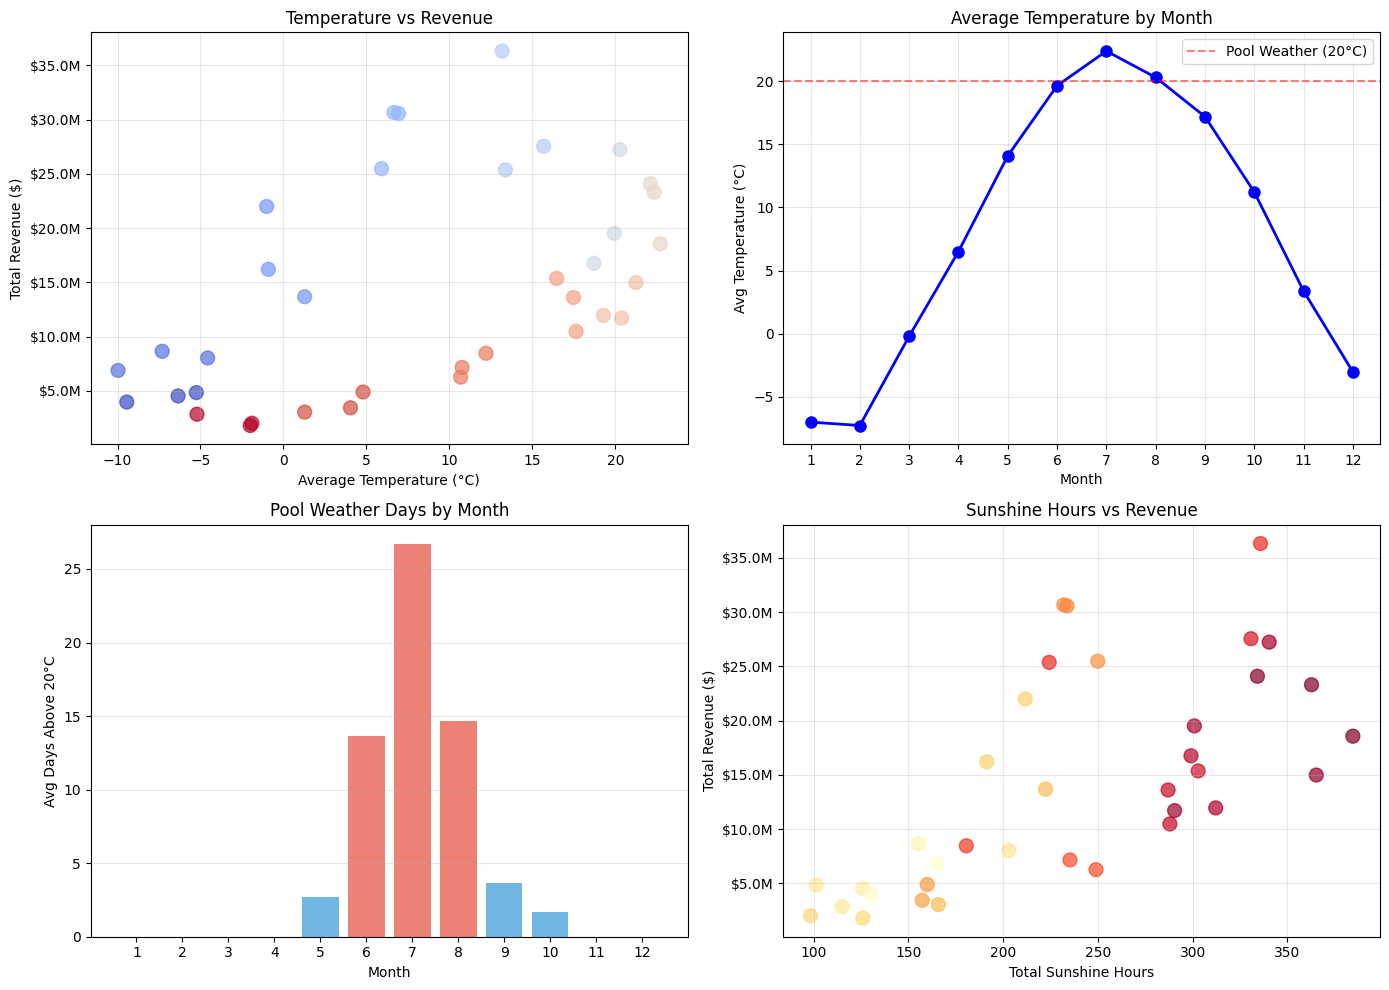

Saved weather analysis plot


In [29]:
# Create reports directory if it doesn't exist
reports_dir = DATA_PROCESSED.parent / 'reports'
reports_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter: Temperature vs Revenue
ax1 = axes[0, 0]
ax1.scatter(sales_spend_weather['avg_temp_mean'], 
            sales_spend_weather['total_all_revenue'],
            c=sales_spend_weather['month_num'],
            cmap='coolwarm', s=100, alpha=0.7)
ax1.set_xlabel('Average Temperature (°C)')
ax1.set_ylabel('Total Revenue ($)')
ax1.set_title('Temperature vs Revenue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.grid(True, alpha=0.3)

# Line: Monthly temperature trend
ax2 = axes[0, 1]
temp_by_month = sales_spend_weather.groupby('month_num')['avg_temp_mean'].mean()
ax2.plot(temp_by_month.index, temp_by_month.values, 'b-o', linewidth=2, markersize=8)
ax2.set_xlabel('Month')
ax2.set_ylabel('Avg Temperature (°C)')
ax2.set_title('Average Temperature by Month')
ax2.set_xticks(range(1, 13))
ax2.grid(True, alpha=0.3)
ax2.axhline(y=20, color='r', linestyle='--', alpha=0.5, label='Pool Weather (20°C)')
ax2.legend()

# Bar: Days above 20°C by month
ax3 = axes[1, 0]
warm_days = sales_spend_weather.groupby('month_num')['days_above_20'].mean()
colors_bar = ['#3498db' if x < 10 else '#e74c3c' for x in warm_days.reindex(range(1, 13), fill_value=0).values]
ax3.bar(range(1, 13), warm_days.reindex(range(1, 13), fill_value=0).values, color=colors_bar, alpha=0.7)
ax3.set_xlabel('Month')
ax3.set_ylabel('Avg Days Above 20°C')
ax3.set_title('Pool Weather Days by Month')
ax3.set_xticks(range(1, 13))
ax3.grid(True, alpha=0.3, axis='y')

# Scatter: Sunshine vs Revenue
ax4 = axes[1, 1]
ax4.scatter(sales_spend_weather['total_sunshine_hours'], 
            sales_spend_weather['total_all_revenue'],
            c=sales_spend_weather['avg_temp_mean'],
            cmap='YlOrRd', s=100, alpha=0.7)
ax4.set_xlabel('Total Sunshine Hours')
ax4.set_ylabel('Total Revenue ($)')
ax4.set_title('Sunshine Hours vs Revenue')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(reports_dir / 'weather_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved weather analysis plot")

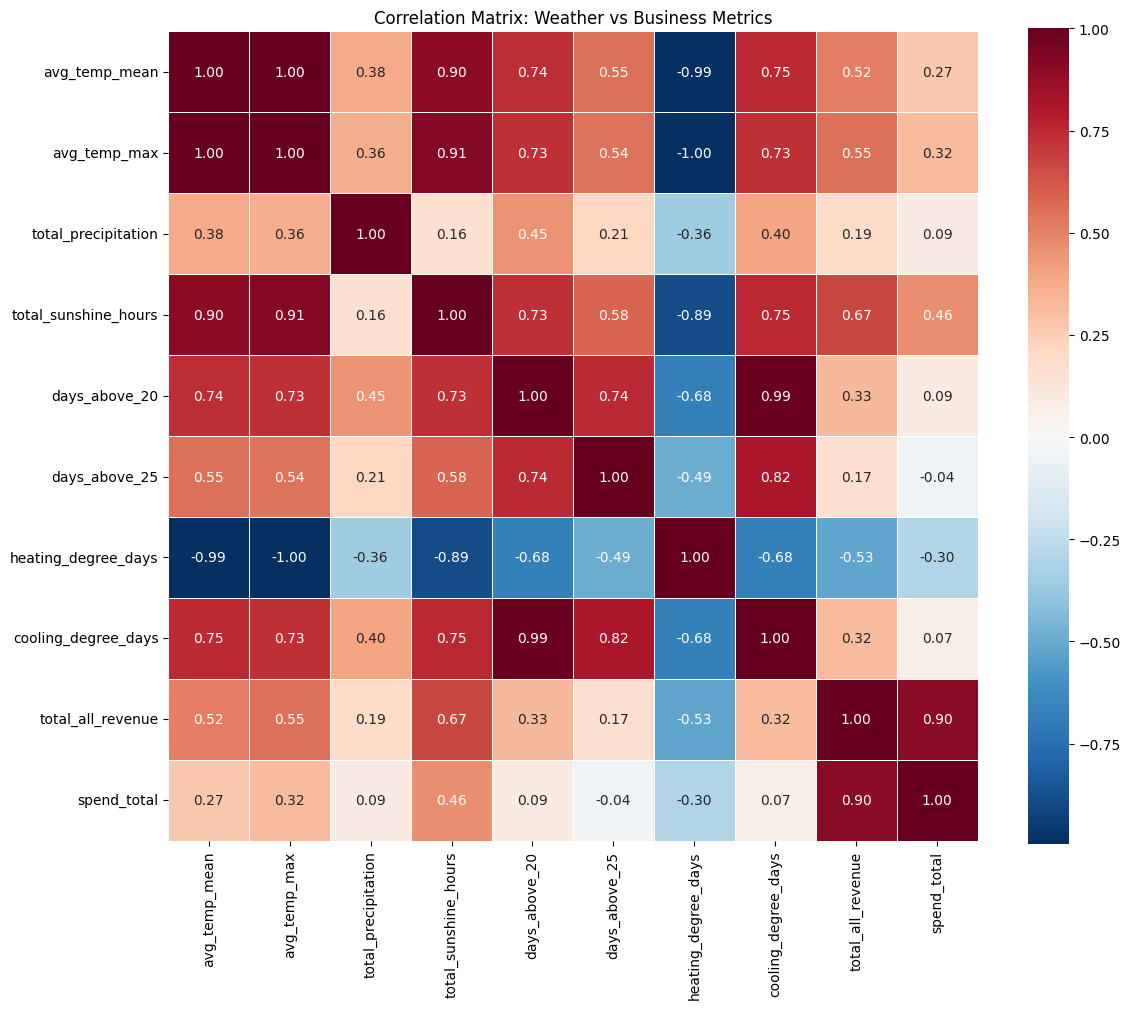


Key correlations with total_all_revenue:
  spend_total               r = +0.904  (STRONG)
  total_sunshine_hours      r = +0.672  (STRONG)
  avg_temp_max              r = +0.553  (STRONG)
  avg_temp_mean             r = +0.515  (STRONG)
  days_above_20             r = +0.329  (MODERATE)
  cooling_degree_days       r = +0.321  (MODERATE)
  total_precipitation       r = +0.191  (WEAK)
  days_above_25             r = +0.168  (WEAK)
  heating_degree_days       r = -0.526  (STRONG)


In [30]:
# Correlation matrix including weather variables
weather_corr_cols = ['avg_temp_mean', 'avg_temp_max', 'total_precipitation', 
                     'total_sunshine_hours', 'days_above_20', 'days_above_25',
                     'heating_degree_days', 'cooling_degree_days']
target_corr_cols = ['total_all_revenue', 'spend_total']

corr_cols = weather_corr_cols + target_corr_cols
available_cols = [c for c in corr_cols if c in sales_spend_weather.columns]

corr_matrix = sales_spend_weather[available_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix: Weather vs Business Metrics')
plt.tight_layout()
plt.savefig(reports_dir / 'weather_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey correlations with total_all_revenue:")
if 'total_all_revenue' in corr_matrix.columns:
    correlations = corr_matrix['total_all_revenue'].drop('total_all_revenue').sort_values(ascending=False)
    for var, corr in correlations.items():
        strength = "STRONG" if abs(corr) > 0.5 else "MODERATE" if abs(corr) > 0.3 else "WEAK"
        print(f"  {var:<25} r = {corr:+.3f}  ({strength})")

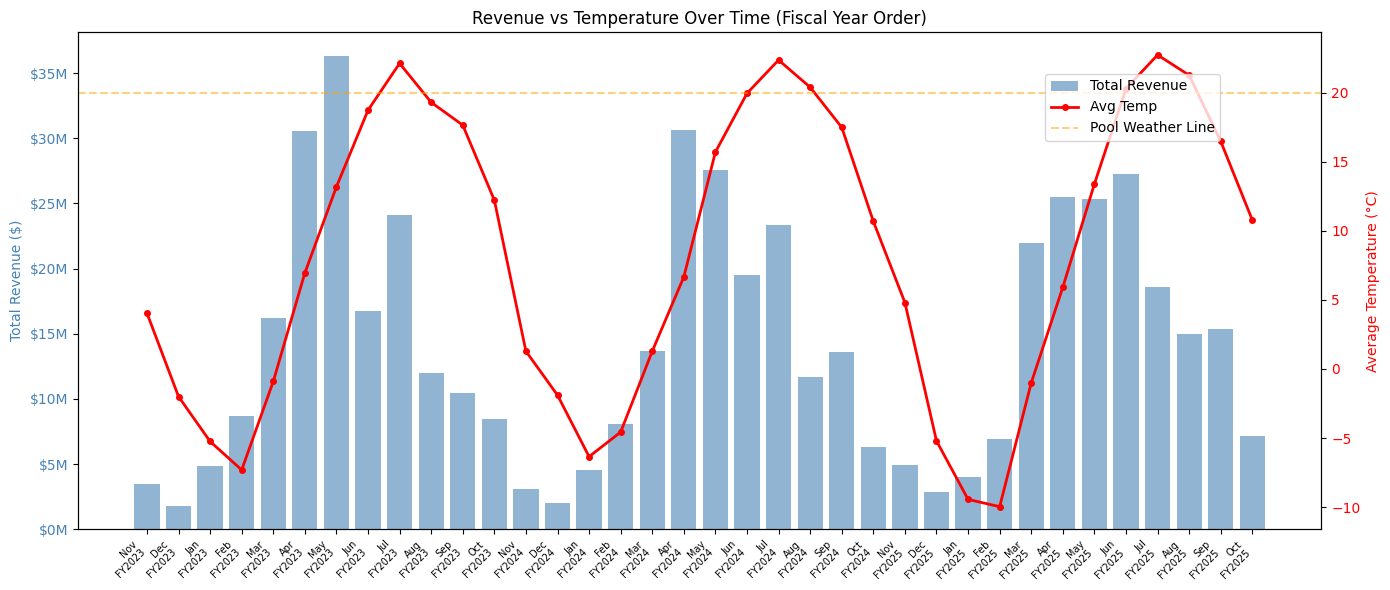

In [31]:
# Overlay: Weather on seasonality chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Use fiscal month position for consistent ordering
sales_spend_weather['fiscal_month_pos'] = sales_spend_weather['month_num'].apply(
    lambda m: m - 10 if m >= 11 else m + 2
)
fiscal_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']

plot_data = sales_spend_weather.sort_values(['year', 'fiscal_month_pos'])
x = range(len(plot_data))

# Bar chart for revenue
ax1.bar(x, plot_data['total_all_revenue'], alpha=0.6, color='steelblue', label='Total Revenue')
ax1.set_ylabel('Total Revenue ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Line for temperature
ax2 = ax1.twinx()
ax2.plot(x, plot_data['avg_temp_mean'], 'r-o', linewidth=2, markersize=4, label='Avg Temp')
ax2.set_ylabel('Average Temperature (°C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='Pool Weather Line')

# X-axis labels
labels = [f"{fiscal_labels[(int(row['fiscal_month_pos'])-1) % 12]}\nFY{int(row['year'])}" 
          for _, row in plot_data.iterrows()]
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)

plt.title('Revenue vs Temperature Over Time (Fiscal Year Order)')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig(reports_dir / 'revenue_vs_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 9: Save Final Datasets

In [32]:
# Save weather data (standalone)
weather_monthly.to_csv(DATA_PROCESSED / 'external_weather.csv', index=False)
weather_monthly.to_pickle(DATA_PROCESSED / 'external_weather.pkl')
print(f"Saved: external_weather.csv ({weather_monthly.shape})")

# Save merged dataset
output_df = sales_spend_weather.copy()
# Drop temporary columns
for col in ['month_cat', 'fiscal_month_pos']:
    if col in output_df.columns:
        output_df = output_df.drop(columns=[col])

output_df.to_csv(DATA_PROCESSED / 'sales_spend_weather.csv', index=False)
output_df.to_pickle(DATA_PROCESSED / 'sales_spend_weather.pkl')
print(f"Saved: sales_spend_weather.csv ({output_df.shape})")
print(f"Saved: sales_spend_weather.pkl")

Saved: external_weather.csv ((36, 15))
Saved: sales_spend_weather.csv ((36, 43))
Saved: sales_spend_weather.pkl


In [33]:
# Final summary
print("="*60)
print("EXTERNAL DATA COLLECTION COMPLETE")
print("="*60)
print(f"\nWeather Data:")
print(f"  Source: Open-Meteo API (historical data)")
print(f"  Location: {LOCATION_NAME} ({LATITUDE}, {LONGITUDE})")
print(f"  Period: {START_DATE} to {END_DATE}")
print(f"  Daily records: {len(weather_daily)}")
print(f"  Monthly records: {len(weather_monthly)}")

print(f"\nHolidays Data:")
print(f"  Quebec statutory holidays (python-holidays)")
print(f"  Years: 2022-2025 (covers FY2023-FY2025)")
print(f"  Records: {len(holidays_df)}")

print(f"\nMerged Dataset:")
print(f"  Shape: {output_df.shape}")
print(f"  Fiscal years: {sorted(output_df['year'].unique())}")

print(f"\nOutput Files:")
print(f"  - external_weather.csv/pkl")
print(f"  - sales_spend_weather.csv/pkl")

print(f"\nColumns ({len(output_df.columns)}):")
for i, col in enumerate(output_df.columns):
    print(f"  {i+1:2d}. {col}")

EXTERNAL DATA COLLECTION COMPLETE

Weather Data:
  Source: Open-Meteo API (historical data)
  Location: Greater Montreal Area (45.55, -73.7)
  Period: 2022-11-01 to 2025-10-31
  Daily records: 1096
  Monthly records: 36

Holidays Data:
  Quebec statutory holidays (python-holidays)
  Years: 2022-2025 (covers FY2023-FY2025)
  Records: 35

Merged Dataset:
  Shape: (36, 43)
  Fiscal years: [np.int64(2023), np.int64(2024), np.int64(2025)]

Output Files:
  - external_weather.csv/pkl
  - sales_spend_weather.csv/pkl

Columns (43):
   1. year
   2. month_num
   3. piscines_hors_terre_units
   4. piscines_hors_terre_revenue
   5. piscines_creusees_units
   6. piscines_creusees_revenue
   7. spas_units
   8. spas_revenue
   9. meubles_gazebo_revenue
  10. fitness_revenue
  11. bbq_revenue
  12. total_all_revenue
  13. total_units
  14. calendar_year
  15. date
  16. month
  17. spend_banniere_web
  18. spend_circulaire_digitale
  19. spend_panneaux
  20. spend_preroll
  21. spend_radio
  22. spen

---
## Next Steps

The merged dataset `sales_spend_weather.pkl` is now ready for:

1. **05_feature_engineering.ipynb** - Add adstock, saturation, and lag features
2. **06_model_building.ipynb** - Build the MMM model

Key weather variables for modeling:
- `avg_temp_mean` - Primary temperature driver
- `days_above_20` - Pool weather indicator  
- `cooling_degree_days` - Heat measure
- `total_sunshine_hours` - Outdoor activity driver
- `heating_degree_days` - Cold measure (negative impact on pool demand)

**Data Sources:**
- Weather: Open-Meteo API (historical data for Montreal)
- Holidays: Quebec statutory holidays (python-holidays package)


NOTEBOOK 05 (Feature Engineering) will load sales_spend_weather.pkl and:
   1. Apply ADSTOCK to spend columns (carryover effect of ads)
   2. Apply SATURATION curves (diminishing returns)
   3. Create LAG features (delayed response)
   
NOTEBOOK 06 (Model Building) will use the transformed data to:
   1. Build MMM: revenue = f(spend, weather, holidays, seasonality)
   2. Calculate ROI per channel
   3. Optimize budget allocation